## **Analysis of stromal gap distances based on Morphometrics results, ST1 vs ST2**

Based on output from Morphometrics.
Run on individual, separated membranes, with only stromal gap distances calculated. 

Run on default MM directory tree, i.e.

    ST1/ 
    |__ tomo1 
         |__ *rh9.csv 
    |__ tomo1 
         |__ *rh9.csv etc

#### Data import:

In [1]:
from pathlib import Path
import os
import re
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)

CONDITION_DIRS = {
    "WL": Path("/scicore/home/engel0006/vandor0000/Sofie_data/tomograms/Cthermalis/segmentations/WL/Morphometrics/"),
    "FRL": Path("/scicore/home/engel0006/vandor0000/Sofie_data/tomograms/Cthermalis/segmentations/FRL/Morphometrics"),
}

CONDITION_COLORS = {
    "WL": "#3986a1",
    "FRL": "#a41858",
}

# use plain AVV files, not excluding1borders
USE_EXCLUDING_BORDERS = False

# subtract this once from every measured distance, unit: nm
MEMBRANE_THICKNESS_NM = 4.95

# Maximum distance cutoff for filtering; set to None to keep all
DISTANCE_CUTOFF_NM = 250

OUTDIR = Path("./morphometrics_distance_analysis")
OUTDIR.mkdir(exist_ok=True)

#### Define functions:

In [19]:
def membrane_num(mem):
    return int(str(mem).replace("T", ""))


def ordered_pair_label(a, b):
    return f"T{min(membrane_num(a), membrane_num(b))}--T{max(membrane_num(a), membrane_num(b))}"


def parse_csv_path(csv_path):
    """
    Robust parser for Morphometrics distance CSVs.

    Works for names like:
      ST1_5-7_Position_17_2_trimed_components_T29.AVV_rh9.csv
      ST1_8-5_Position_5_thylakoids_morphometrics_T14.AVV_rh9.csv
      ..._T14.AVV_rh9_excluding1borders.csv

    Assumes:
      - tomogram name = parent directory name
      - source membrane = final _T<number> before .AVV_rh9...
    """
    csv_path = Path(csv_path)
    tomogram = csv_path.parent.name

    m = re.search(
        r"_(T\d+)\.AVV_rh9(?:_excluding1borders)?\.csv$",
        csv_path.name
    )
    if m is None:
        return tomogram, None

    source_membrane = m.group(1)
    return tomogram, source_membrane


def is_distance_csv(filename, use_excluding_borders=False):
    """
    Keep only Morphometrics distance CSVs.
    Exclude runtimes and non-CSV sidecar files.
    """
    name = str(filename)

    if not name.endswith(".csv"):
        return False

    if "_runtimes.csv" in name:
        return False

    if ".AVV_rh9" not in name:
        return False

    if use_excluding_borders:
        return name.endswith(".AVV_rh9_excluding1borders.csv")
    else:
        return name.endswith(".AVV_rh9.csv") and ("_excluding1borders.csv" not in name)


def find_distance_csvs(root_dir, use_excluding_borders=False):
    root_dir = Path(root_dir)
    csv_files = []

    for dp, dn, fn in os.walk(root_dir, followlinks=True):
        for f in fn:
            if is_distance_csv(f, use_excluding_borders=use_excluding_borders):
                csv_files.append(Path(dp) / f)

    return sorted(csv_files)


def find_config_near_csv(csv_path):
    """
    Search for config yaml in:
    1) same directory as csv
    2) parent directory
    """
    search_dirs = [csv_path.parent, csv_path.parent.parent]

    for directory in search_dirs:
        if not directory.exists():
            continue

        candidates = (
            sorted(directory.glob("*config*.yml")) +
            sorted(directory.glob("*config*.yaml")) +
            sorted(directory.glob("*.yml")) +
            sorted(directory.glob("*.yaml"))
        )

        for path in candidates:
            try:
                with open(path, "r") as f:
                    cfg = yaml.safe_load(f)
                if isinstance(cfg, dict) and "distance_and_orientation_measurements" in cfg:
                    return path
            except Exception:
                pass

    return None


def load_directed_pairs_from_config(config_path):
    """
    Returns directed pairs as tuples:
    {("T2", "T3"), ("T4", "T5"), ...}
    """
    if config_path is None:
        return None

    with open(config_path, "r") as f:
        cfg = yaml.safe_load(f)

    inter = cfg.get("distance_and_orientation_measurements", {}).get("inter", {})
    directed_pairs = set()

    for src, tgts in inter.items():
        if tgts is None:
            continue
        for tgt in tgts:
            directed_pairs.add((src, tgt))

    return directed_pairs


def keep_direction(source_membrane, target_membrane, directed_pairs):
    """
    If config-directed pairs exist, keep only those exact directions.
    Otherwise keep only one canonical direction:
    smaller T number -> larger T number.
    """
    if directed_pairs is not None:
        return (source_membrane, target_membrane) in directed_pairs, "config_direction"

    return membrane_num(source_membrane) < membrane_num(target_membrane), "numeric_direction"


def weighted_quantile(values, quantiles, sample_weight=None):
    values = np.asarray(values, dtype=float)
    quantiles = np.asarray(quantiles, dtype=float)

    if sample_weight is None:
        sample_weight = np.ones_like(values, dtype=float)
    else:
        sample_weight = np.asarray(sample_weight, dtype=float)

    mask = np.isfinite(values) & np.isfinite(sample_weight) & (sample_weight > 0)
    values = values[mask]
    sample_weight = sample_weight[mask]

    if values.size == 0:
        return np.full(quantiles.shape, np.nan, dtype=float)

    sorter = np.argsort(values)
    values = values[sorter]
    sample_weight = sample_weight[sorter]

    cumulative = np.cumsum(sample_weight) - 0.5 * sample_weight
    cumulative = cumulative / np.sum(sample_weight)

    return np.interp(quantiles, cumulative, values)


def summarise_distances(g):
    vals = g["distance"].to_numpy()
    areas = g["area"].to_numpy()

    q25_w, q50_w, q75_w = weighted_quantile(vals, [0.25, 0.50, 0.75], areas)

    return pd.Series({
        "n_vertices": len(g),
        "area_total": np.nansum(areas),
        "distance_mean": np.nanmean(vals),
        "distance_median": np.nanmedian(vals),
        "distance_std": np.nanstd(vals, ddof=1) if len(vals) > 1 else np.nan,
        "distance_mean_weighted": np.average(vals, weights=areas),
        "distance_median_weighted": q50_w,
        "distance_q25_weighted": q25_w,
        "distance_q75_weighted": q75_w,
    })


def collect_distance_rows(root_dir, condition, use_excluding_borders=False):
    """
    Collect all usable directed distances under one condition parent directory.

    Important:
    - membrane labels are local to each tomogram
    - each pair instance is unique within a tomogram
    - only one direction per pair is kept
    """
    root_dir = Path(root_dir)

    all_parts = []
    skipped = []
    debug_rows = []

    csv_files = find_distance_csvs(root_dir, use_excluding_borders=use_excluding_borders)

    for csv_path in csv_files:
        tomogram, source_membrane = parse_csv_path(csv_path)
        if source_membrane is None:
            skipped.append((str(csv_path), "name_parse_failed"))
            continue

        config_path = find_config_near_csv(csv_path)
        directed_pairs = load_directed_pairs_from_config(config_path)

        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            skipped.append((str(csv_path), f"read_failed: {e}"))
            continue

        dist_cols = [c for c in df.columns if c.endswith("_dist")]

        debug_entry = {
            "csv_file": str(csv_path),
            "tomogram": tomogram,
            "source_membrane": source_membrane,
            "config_file": str(config_path) if config_path else None,
            "n_dist_cols": len(dist_cols),
            "dist_cols_found": ",".join(dist_cols),
            "pair_candidates": "",
            "pairs_kept": "",
            "n_rows_in_csv": len(df),
            "n_rows_kept_total": 0,
        }

        if not dist_cols:
            skipped.append((str(csv_path), "no_distance_columns"))
            debug_rows.append(debug_entry)
            continue

        pair_candidates = []
        pairs_kept = []

        for dist_col in dist_cols:
            target_membrane = dist_col[:-5]
            pair_candidates.append(f"{source_membrane}->{target_membrane}")

            keep, rule = keep_direction(source_membrane, target_membrane, directed_pairs)
            if not keep:
                continue

            sub = df[["area", dist_col]].copy()
            sub = sub.rename(columns={dist_col: "distance_raw_nm"})
            sub = sub[np.isfinite(sub["distance_raw_nm"])].copy()

            if sub.empty:
                continue

            sub["distance"] = np.clip(sub["distance_raw_nm"] - MEMBRANE_THICKNESS_NM, 0, None)
            sub["membrane_thickness_subtracted_nm"] = MEMBRANE_THICKNESS_NM

            pair_instance_id = f"{tomogram}::{source_membrane}->{target_membrane}"
            unordered_pair_instance_id = f"{tomogram}::{ordered_pair_label(source_membrane, target_membrane)}"
            source_instance_id = f"{tomogram}::{source_membrane}"

            sub["condition"] = condition
            sub["tomogram"] = tomogram
            sub["source_membrane"] = source_membrane
            sub["target_membrane"] = target_membrane
            sub["pair_label_local"] = f"{source_membrane}->{target_membrane}"
            sub["unordered_pair_label_local"] = ordered_pair_label(source_membrane, target_membrane)
            sub["pair_instance_id"] = pair_instance_id
            sub["unordered_pair_instance_id"] = unordered_pair_instance_id
            sub["source_instance_id"] = source_instance_id
            sub["direction_rule"] = rule
            sub["csv_file"] = str(csv_path)
            sub["config_file"] = str(config_path) if config_path is not None else None

            pairs_kept.append(f"{source_membrane}->{target_membrane}")
            debug_entry["n_rows_kept_total"] += len(sub)
            all_parts.append(sub)

        debug_entry["pair_candidates"] = ",".join(pair_candidates)
        debug_entry["pairs_kept"] = ",".join(pairs_kept)
        debug_rows.append(debug_entry)

    if all_parts:
        out = pd.concat(all_parts, ignore_index=True)
    else:
        out = pd.DataFrame(columns=[
            "area", "distance_raw_nm", "distance", "membrane_thickness_subtracted_nm",
            "condition", "tomogram", "source_membrane", "target_membrane",
            "pair_label_local", "unordered_pair_label_local",
            "pair_instance_id", "unordered_pair_instance_id", "source_instance_id",
            "direction_rule", "csv_file", "config_file"
        ])

    skipped_df = pd.DataFrame(skipped, columns=["file", "reason"])
    debug_df = pd.DataFrame(debug_rows)

    return out, skipped_df, debug_df


def compare_two_conditions(df, value_col, condition_order=None):
    if condition_order is None:
        condition_order = list(CONDITION_DIRS.keys())

    a_name, b_name = condition_order
    a = df.loc[df["condition"] == a_name, value_col].dropna().to_numpy()
    b = df.loc[df["condition"] == b_name, value_col].dropna().to_numpy()

    p = np.nan
    if len(a) >= 2 and len(b) >= 2:
        _, p = mannwhitneyu(a, b, alternative="two-sided")

    return pd.DataFrame([{
        "value_col": value_col,
        f"n_{a_name}": len(a),
        f"n_{b_name}": len(b),
        f"median_{a_name}": np.median(a) if len(a) else np.nan,
        f"median_{b_name}": np.median(b) if len(b) else np.nan,
        f"mean_{a_name}": np.mean(a) if len(a) else np.nan,
        f"mean_{b_name}": np.mean(b) if len(b) else np.nan,
        f"delta_median_{a_name}_minus_{b_name}": (np.median(a) - np.median(b)) if len(a) and len(b) else np.nan,
        "p_value_mannwhitney": p,
    }])


def plot_violin_with_points(df, value_col, ylabel=None, title=None, condition_order=None):
    """
    Violin plot with jittered points for pooled summaries by condition.
    """
    if condition_order is None:
        condition_order = list(CONDITION_DIRS.keys())

    fig, ax = plt.subplots(figsize=(5.0, 4.8))
    rng = np.random.default_rng(0)

    data = []
    positions = np.arange(1, len(condition_order) + 1)

    for cond in condition_order:
        vals = df.loc[df["condition"] == cond, value_col].dropna().to_numpy()
        data.append(vals)

    violin = ax.violinplot(
        data,
        positions=positions,
        widths=0.8,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )

    for body, cond in zip(violin["bodies"], condition_order):
        body.set_facecolor(CONDITION_COLORS.get(cond, "gray"))
        body.set_edgecolor(CONDITION_COLORS.get(cond, "gray"))
        body.set_alpha(0.35)

    if "cmedians" in violin:
        violin["cmedians"].set_color("black")
        violin["cmedians"].set_linewidth(1.5)

    for i, cond in enumerate(condition_order, start=1):
        vals = df.loc[df["condition"] == cond, value_col].dropna().to_numpy()
        if len(vals) == 0:
            continue

        x = rng.normal(i, 0.05, size=len(vals))
        ax.plot(
            x, vals, "o",
            ms=4.5,
            alpha=0.7,
            color=CONDITION_COLORS.get(cond, None)
        )

    ax.set_xticks(positions)
    ax.set_xticklabels(condition_order)
    ax.set_ylabel(ylabel if ylabel else value_col)
    if title:
        ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    plt.show()


def plot_vertex_histograms(vertex_df, bins=80, density=False, xlim=None, condition_order=None):
    """
    Per-vertex pooled histogram across the full dataset.

    density=False:
        each condition histogram is normalized to its own maximum count = 1

    density=True:
        standard probability density histogram (area under curve = 1)

    xlim:
        tuple like (0, 40)
    """
    if condition_order is None:
        condition_order = list(CONDITION_DIRS.keys())

    vals_all = vertex_df["distance"].dropna().to_numpy()
    if xlim is not None:
        xmin, xmax = xlim
        vals_all = vals_all[(vals_all >= xmin) & (vals_all <= xmax)]

    if len(vals_all) == 0:
        print("No vertex distances found.")
        return

    bin_edges = np.histogram_bin_edges(vals_all, bins=bins)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    fig, ax = plt.subplots(figsize=(7.0, 4.8))

    for cond in condition_order:
        vals = vertex_df.loc[vertex_df["condition"] == cond, "distance"].dropna().to_numpy()

        if xlim is not None:
            vals = vals[(vals >= xmin) & (vals <= xmax)]

        if len(vals) == 0:
            continue

        color = CONDITION_COLORS.get(cond, None)

        if density:
            counts, _ = np.histogram(vals, bins=bin_edges, density=True)
            y = counts
            ylabel = "density"
        else:
            counts, _ = np.histogram(vals, bins=bin_edges, density=False)
            if counts.max() == 0:
                continue
            y = counts / counts.max()
            ylabel = "normalized count (max=1)"

        ax.plot(centers, y, linewidth=2, color=color, label=f"{cond} (n={len(vals)})")
        ax.fill_between(centers, 0, y, color=color, alpha=0.2)

    ax.set_xlabel("distance (nm)")
    ax.set_ylabel(ylabel)
    ax.set_title("Per-vertex pooled distance distribution")
    if xlim is not None:
        ax.set_xlim(xlim)
    ax.legend(frameon=False)
    ax.grid(alpha=0.25)
    plt.show()

def plot_violin_with_boxplot(df, value_col, ylabel=None, title=None, condition_order=None, save_svg=None):
    """
    Violin plot with overlaid boxplot and point cloud.
    Shows both median (line in boxplot) and mean (triangle marker).
    
    Parameters:
    - df: DataFrame with 'condition' column and value_col
    - value_col: column name to plot
    - ylabel: y-axis label
    - title: plot title
    - condition_order: list of condition names in desired order
    """
    if condition_order is None:
        condition_order = list(CONDITION_DIRS.keys())

    fig, ax = plt.subplots(figsize=(5.0, 4.8))
    rng = np.random.default_rng(0)

    data = []
    positions = np.arange(1, len(condition_order) + 1)

    for cond in condition_order:
        vals = df.loc[df["condition"] == cond, value_col].dropna().to_numpy()
        data.append(vals)

    # Create violin plot
    violin = ax.violinplot(
        data,
        positions=positions,
        widths=0.7,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    for body, cond in zip(violin["bodies"], condition_order):
        body.set_facecolor(CONDITION_COLORS.get(cond, "gray"))
        body.set_edgecolor(CONDITION_COLORS.get(cond, "gray"))
        body.set_alpha(0.25)

    # Overlay boxplot
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.3,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(linewidth=1.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        medianprops=dict(color="black", linewidth=2)
    )

    # Color the boxes
    for patch, cond in zip(bp["boxes"], condition_order):
        patch.set_facecolor(CONDITION_COLORS.get(cond, "gray"))
        patch.set_alpha(0.7)

    # Add mean markers (triangle)
    for i, cond in enumerate(condition_order, start=1):
        vals = df.loc[df["condition"] == cond, value_col].dropna().to_numpy()
        if len(vals) > 0:
            mean_val = np.mean(vals)
            ax.plot(i, mean_val, marker="^", markersize=8, color="red", 
                   markeredgecolor="darkred", markeredgewidth=1, zorder=3, label="mean" if i == 1 else "")

    # Add individual points (jittered)
    for i, cond in enumerate(condition_order, start=1):
        vals = df.loc[df["condition"] == cond, value_col].dropna().to_numpy()
        if len(vals) == 0:
            continue

        x = rng.normal(i, 0.04, size=len(vals))
        ax.plot(
            x, vals, "o",
            ms=3.5,
            alpha=0.5,
            color=CONDITION_COLORS.get(cond, None)
        )

    ax.set_xticks(positions)
    ax.set_xticklabels(condition_order)
    ax.set_ylabel(ylabel if ylabel else value_col)
    if title:
        ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    
    # Add legend for mean marker
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker="^", color="w", markerfacecolor="red", 
                             markeredgecolor="darkred", markersize=8, label="Mean")]
    ax.legend(handles=legend_elements, loc="best", frameon=False)
    
    if save_svg:
       plt.savefig(save_svg, format='svg', dpi=300, bbox_inches='tight')
       print(f"✓ Saved to {save_svg}")
   

       
    plt.show()


#### Gather data and debug:

In [3]:
for condition, root in CONDITION_DIRS.items():
    print(f"\n{condition}: {root}")
    print("exists:", root.exists())
    print("is_dir:", root.is_dir())

    if root.exists():
        files = find_distance_csvs(
            root,
            use_excluding_borders=USE_EXCLUDING_BORDERS
        )
        print("matching distance csv files:", len(files))


WL: /scicore/home/engel0006/vandor0000/Sofie_data/tomograms/Cthermalis/segmentations/WL/Morphometrics
exists: True
is_dir: True
matching distance csv files: 109

FRL: /scicore/home/engel0006/vandor0000/Sofie_data/tomograms/Cthermalis/segmentations/FRL/Morphometrics
exists: True
is_dir: True
matching distance csv files: 144


In [4]:
all_vertex_dfs = []
all_skipped_dfs = []
all_debug_dfs = []

for condition, root_dir in CONDITION_DIRS.items():
    vertex_df_cond, skipped_df_cond, debug_df_cond = collect_distance_rows(
        root_dir=root_dir,
        condition=condition,
        use_excluding_borders=USE_EXCLUDING_BORDERS
    )

    print(f"\nCondition: {condition}")
    print(f"  root: {root_dir}")
    print(f"  csv files checked: {len(debug_df_cond)}")
    print(f"  usable rows: {len(vertex_df_cond)}")

    all_vertex_dfs.append(vertex_df_cond)
    all_skipped_dfs.append(skipped_df_cond)
    all_debug_dfs.append(debug_df_cond)

vertex_df = pd.concat(all_vertex_dfs, ignore_index=True)
skipped_df = pd.concat(all_skipped_dfs, ignore_index=True)
debug_df = pd.concat(all_debug_dfs, ignore_index=True)

# Apply distance cutoff filter if specified
if DISTANCE_CUTOFF_NM is not None:
    n_before = len(vertex_df)
    vertex_df = vertex_df[vertex_df["distance"] <= DISTANCE_CUTOFF_NM].copy()
    n_after = len(vertex_df)
    n_removed = n_before - n_after
    print(f"\n⚠ Distance cutoff applied: DISTANCE_CUTOFF_NM = {DISTANCE_CUTOFF_NM} nm")
    print(f"   Removed {n_removed} vertices ({100*n_removed/n_before:.1f}%) beyond cutoff")
    print(f"   Retained: {n_after} vertices")

print("\nTotal usable rows:", len(vertex_df))
print("Unique tomograms:", vertex_df["tomogram"].nunique())
print("Unique pair instances:", vertex_df["pair_instance_id"].nunique())

vertex_df.to_csv(OUTDIR / "all_directed_vertex_distances.csv", index=False)
debug_df.to_csv(OUTDIR / "distance_debug_table.csv", index=False)
skipped_df.to_csv(OUTDIR / "distance_skipped_files.csv", index=False)


Condition: WL
  root: /scicore/home/engel0006/vandor0000/Sofie_data/tomograms/Cthermalis/segmentations/WL/Morphometrics
  csv files checked: 109
  usable rows: 1453940

Condition: FRL
  root: /scicore/home/engel0006/vandor0000/Sofie_data/tomograms/Cthermalis/segmentations/FRL/Morphometrics
  csv files checked: 144
  usable rows: 2976940

⚠ Distance cutoff applied: DISTANCE_CUTOFF_NM = 250 nm
   Removed 158628 vertices (3.6%) beyond cutoff
   Retained: 4272252 vertices

Total usable rows: 4272252
Unique tomograms: 11
Unique pair instances: 97


In [5]:
pair_instance_summary_df = (
    vertex_df
    .groupby(
        ["condition", "tomogram", "source_membrane", "target_membrane",
         "pair_label_local", "unordered_pair_label_local",
         "pair_instance_id", "unordered_pair_instance_id"],
        group_keys=False
    )
    .apply(summarise_distances)
    .reset_index()
)

display(pair_instance_summary_df.head())

pair_instance_summary_df.to_csv(
    OUTDIR / "distance_summary_per_pair_instance.csv",
    index=False
)

/scratch/vandor0000/slurm-job.20258503/ipykernel_3925508/3611913385.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarise_distances)


,condition,tomogram,source_membrane,target_membrane,pair_label_local,unordered_pair_label_local,pair_instance_id,unordered_pair_instance_id,n_vertices,area_total,distance_mean,distance_median,distance_std,distance_mean_weighted,distance_median_weighted,distance_q25_weighted,distance_q75_weighted
0,FRL,28,T10,T11,T10->T11,T10--T11,28::T10->T11,28::T10--T11,69371.0,212189.466117,85.351797,66.801000,47.808702,84.984696,66.834578,61.612421,74.833818
1,FRL,28,T12,T13,T12->T13,T12--T13,28::T12->T13,28::T12--T13,54191.0,160315.597608,53.472289,54.723746,14.589918,53.429452,54.685735,38.941604,67.148556
2,FRL,28,T14,T15,T14->T15,T14--T15,28::T14->T15,28::T14--T15,59881.0,163233.959313,54.391034,49.733193,17.737014,54.806133,50.789185,40.385062,65.674658
3,FRL,28,T16,T17,T16->T17,T16--T17,28::T16->T17,28::T16--T17,51917.0,151097.370908,64.216301,66.407979,13.208860,64.218419,66.309206,55.850015,73.786237
4,FRL,28,T2,T3,T2->T3,T2--T3,28::T2->T3,28::T2--T3,65752.0,194197.546652,45.629048,44.408684,12.719795,45.440601,44.136627,33.892957,56.726744


In [6]:
tomogram_summary_df = (
    vertex_df
    .groupby(["condition", "tomogram"], group_keys=False)
    .apply(summarise_distances)
    .reset_index()
)

display(tomogram_summary_df.head())

tomogram_summary_df.to_csv(
    OUTDIR / "distance_summary_per_tomogram.csv",
    index=False
)

/scratch/vandor0000/slurm-job.20258503/ipykernel_3925508/898064085.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarise_distances)


,condition,tomogram,n_vertices,area_total,distance_mean,distance_median,distance_std,distance_mean_weighted,distance_median_weighted,distance_q25_weighted,distance_q75_weighted
0,FRL,28,591244.0,1.742731e+06,54.193115,48.968344,30.816164,54.151413,49.002544,34.056855,65.325709
1,FRL,35,794631.0,1.820249e+06,54.410456,61.557967,23.879200,51.554715,59.844597,24.914571,65.732082
2,FRL,38,717829.0,1.285425e+06,31.889275,23.725803,24.955683,43.161797,46.427834,23.533135,55.987080
3,FRL,48,324378.0,8.913408e+05,54.541058,47.458727,27.644186,55.423405,49.721296,37.121172,66.820239
4,FRL,50,288857.0,5.952298e+05,65.413766,58.627294,35.171122,67.997201,56.606634,35.261223,96.646759


In [7]:
source_membrane_summary_df = (
    vertex_df
    .groupby(
        ["condition", "tomogram", "source_membrane", "source_instance_id"],
        group_keys=False
    )
    .apply(summarise_distances)
    .reset_index()
)

display(source_membrane_summary_df.head())

source_membrane_summary_df.to_csv(
    OUTDIR / "distance_summary_per_source_membrane.csv",
    index=False
)

/scratch/vandor0000/slurm-job.20258503/ipykernel_3925508/43485488.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarise_distances)


,condition,tomogram,source_membrane,source_instance_id,n_vertices,area_total,distance_mean,distance_median,distance_std,distance_mean_weighted,distance_median_weighted,distance_q25_weighted,distance_q75_weighted
0,FRL,28,T10,28::T10,69371.0,212189.466117,85.351797,66.801000,47.808702,84.984696,66.834578,61.612421,74.833818
1,FRL,28,T12,28::T12,54191.0,160315.597608,53.472289,54.723746,14.589918,53.429452,54.685735,38.941604,67.148556
2,FRL,28,T14,28::T14,59881.0,163233.959313,54.391034,49.733193,17.737014,54.806133,50.789185,40.385062,65.674658
3,FRL,28,T16,28::T16,51917.0,151097.370908,64.216301,66.407979,13.208860,64.218419,66.309206,55.850015,73.786237
4,FRL,28,T2,28::T2,65752.0,194197.546652,45.629048,44.408684,12.719795,45.440601,44.136627,33.892957,56.726744


#### **Plots:**

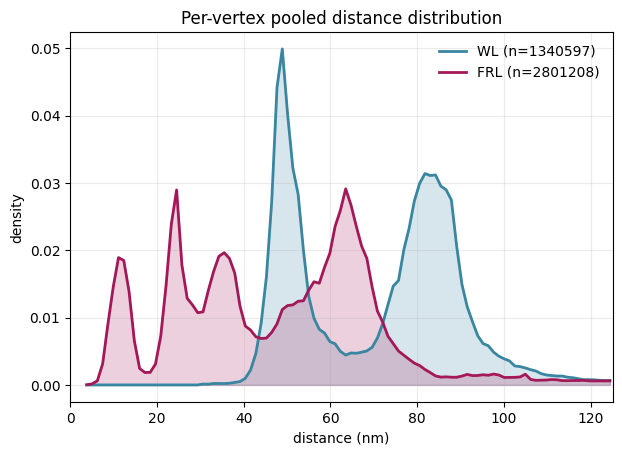

In [8]:
plot_vertex_histograms(
    vertex_df,
    bins=100,
    density=True,
    xlim=(0, 125),
    
)

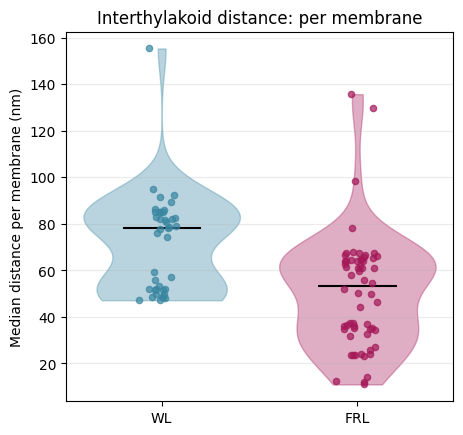

,value_col,n_WL,n_FRL,median_WL,median_FRL,mean_WL,mean_FRL,delta_median_WL_minus_FRL,p_value_mannwhitney
0,distance_median,40,60,78.053873,53.327215,71.640892,50.635276,24.726658,0.000024


In [12]:
plot_violin_with_points(
    source_membrane_summary_df,
    value_col="distance_median",
    ylabel="Median distance per membrane (nm)",
    title="Interthylakoid distance: per membrane"
)

source_membrane_stats_df = compare_two_conditions(
    source_membrane_summary_df,
    value_col="distance_median"
)

display(source_membrane_stats_df)
source_membrane_stats_df.to_csv(
    OUTDIR / "stats_source_median",
    index=False
)

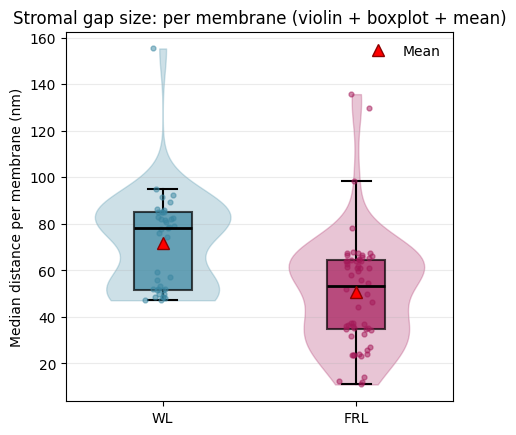

✓ Saved to mean_interthylakoid_distance_FRLWL.svg


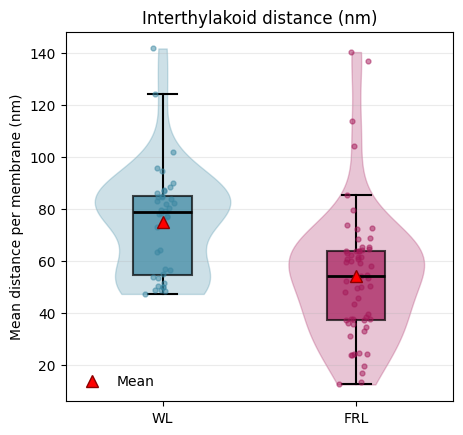

In [20]:
plot_violin_with_boxplot(
    source_membrane_summary_df,
    value_col="distance_median",
    ylabel="Median distance per membrane (nm)",
    title="Stromal gap size: per membrane (violin + boxplot + mean)"
)

# Also show mean-based analysis for comparison
plot_violin_with_boxplot(
    source_membrane_summary_df,
    value_col="distance_mean",
    ylabel="Mean distance per membrane (nm)",
    title="Interthylakoid distance (nm)",
    save_svg="mean_interthylakoid_distance_FRLWL.svg"
)


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvista as pv

def normalize_rows(v):
    v = np.asarray(v, dtype=float)
    n = np.linalg.norm(v, axis=1, keepdims=True)
    good = n[:, 0] > 0
    out = np.zeros_like(v, dtype=float)
    out[good] = v[good] / n[good]
    return out, good


def normalize_vec(v):
    v = np.asarray(v, dtype=float)
    n = np.linalg.norm(v)
    if n == 0:
        raise ValueError("Zero-length vector.")
    return v / n


def make_projection_basis_from_viewdir(view_dir):
    """
    Build a 2D projection basis whose viewing direction is `view_dir`.
    The returned basis vectors span the plane perpendicular to view_dir.
    """
    ez = normalize_vec(view_dir)

    helper = np.array([0.0, 0.0, 1.0])
    if abs(np.dot(ez, helper)) > 0.9:
        helper = np.array([0.0, 1.0, 0.0])

    ex = np.cross(helper, ez)
    ex = normalize_vec(ex)

    ey = np.cross(ez, ex)
    ey = normalize_vec(ey)

    basis = np.stack([ex, ey], axis=1)   # shape (3, 2)
    return basis, ez


def project_points(points_3d, origin_3d, basis_3x2):
    pts = np.asarray(points_3d, dtype=float) - np.asarray(origin_3d, dtype=float)
    return pts @ basis_3x2


def polydata_triangle_edges(poly):
    """
    Return unique polygon edges as pairs of point indices from a PyVista PolyData.
    Works for triangulated surfaces.
    """
    faces = poly.faces
    edges = set()

    i = 0
    while i < len(faces):
        n = int(faces[i])
        ids = faces[i + 1:i + 1 + n]
        if n >= 3:
            for j in range(n):
                a = int(ids[j])
                b = int(ids[(j + 1) % n])
                edges.add(tuple(sorted((a, b))))
        i += n + 1

    return np.array(sorted(edges), dtype=int)


def draw_projected_mesh_edges(ax, points_2d, edges, color, lw=0.4, alpha=0.45):
    for a, b in edges:
        ax.plot(
            [points_2d[a, 0], points_2d[b, 0]],
            [points_2d[a, 1], points_2d[b, 1]],
            color=color,
            lw=lw,
            alpha=alpha
        )


def coerce_to_surface_polydata(obj):
    """
    Convert a PyVista read object into one PolyData surface.

    Handles:
    - PolyData
    - UnstructuredGrid / other datasets with extract_surface()
    - MultiBlock
    """
    if isinstance(obj, pv.PolyData):
        return obj.triangulate()

    if isinstance(obj, pv.MultiBlock):
        if len(obj) == 0:
            raise ValueError("MultiBlock mesh is empty.")

        try:
            # easiest route if supported
            merged = obj.combine()
            return merged.extract_surface().triangulate()
        except Exception:
            polys = []
            for block in obj:
                if block is None:
                    continue
                poly = coerce_to_surface_polydata(block)
                if poly.n_points > 0:
                    polys.append(poly)

            if not polys:
                raise ValueError("MultiBlock contained no usable mesh blocks.")

            merged = polys[0]
            for poly in polys[1:]:
                merged = merged.merge(poly, merge_points=False)

            return merged.extract_surface().triangulate()

    if hasattr(obj, "extract_surface"):
        return obj.extract_surface().triangulate()

    raise TypeError(f"Unsupported mesh type: {type(obj)}")


def read_surface_polydata(path):
    obj = pv.read(path)
    poly = coerce_to_surface_polydata(obj)

    if poly.n_points == 0:
        raise ValueError(f"No surface points found in: {path}")

    return poly

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvista as pv
from scipy.spatial import cKDTree


def plot_projected_mesh_pair_with_distances(
    source_mesh_path,
    target_mesh_path,
    csv_path,
    dist_col,
    vector_cols=("avg_normals_x", "avg_normals_y", "avg_normals_z"),
    step=25,
    xlim=None,
    ylim=None,
    source_color="lightseagreen",
    target_color="purple",
    line_color="black",
    source_lw=0.4,
    target_lw=0.4,
    line_lw=0.8,
    line_alpha=0.5,
    title=None
):
    # --- load meshes ---
    src_mesh = read_surface_polydata(source_mesh_path)
    tgt_mesh = read_surface_polydata(target_mesh_path)

    # --- load csv ---
    df = pd.read_csv(csv_path).copy()

    required = ["xyz_x", "xyz_y", "xyz_z", dist_col, *vector_cols]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    keep = np.isfinite(df[dist_col].to_numpy(float))
    for c in vector_cols:
        keep &= np.isfinite(df[c].to_numpy(float))
    df = df.loc[keep].copy()

    if df.empty:
        raise ValueError("No finite rows available for plotting.")

    src_xyz = df[["xyz_x", "xyz_y", "xyz_z"]].to_numpy(float)
    vec = df[list(vector_cols)].to_numpy(float)
    dist = df[dist_col].to_numpy(float)

    vec_unit, good = normalize_rows(vec)
    src_xyz = src_xyz[good]
    vec_unit = vec_unit[good]
    dist = dist[good]

    if len(src_xyz) == 0:
        raise ValueError("No valid direction vectors after normalization.")

    # --- choose sign using proximity to target mesh ---
    tgt_tree = cKDTree(tgt_mesh.points)

    cand_plus = src_xyz + vec_unit * dist[:, None]
    cand_minus = src_xyz - vec_unit * dist[:, None]

    d_plus, _ = tgt_tree.query(cand_plus, k=1)
    d_minus, _ = tgt_tree.query(cand_minus, k=1)

    use_plus = d_plus <= d_minus
    line_src = src_xyz
    line_tgt = np.where(use_plus[:, None], cand_plus, cand_minus)

    # use chosen line directions to define mean viewing direction
    chosen_dirs = line_tgt - line_src
    chosen_dirs = chosen_dirs / np.linalg.norm(chosen_dirs, axis=1, keepdims=True)
    mean_dir = normalize_vec(chosen_dirs.mean(axis=0))
    
    # original face-on basis:
    basis_face, ez = make_projection_basis_from_viewdir(mean_dir)
    ex = basis_face[:, 0]
    ey = basis_face[:, 1]
    
    # rotated by 90° around projected x-axis:
    # old plane was (ex, ey), viewed along ez
    # new plane is (ex, ez), viewed along ey
    basis = np.stack([ex, ez], axis=1)
    view_dir = ey

    all_mesh_pts = np.vstack([src_mesh.points, tgt_mesh.points])
    origin = all_mesh_pts.mean(axis=0)

    src_pts_2d = project_points(src_mesh.points, origin, basis)
    tgt_pts_2d = project_points(tgt_mesh.points, origin, basis)

    src_edges = polydata_triangle_edges(src_mesh)
    tgt_edges = polydata_triangle_edges(tgt_mesh)

    line_src_2d = project_points(line_src, origin, basis)
    line_tgt_2d = project_points(line_tgt, origin, basis)

    fig, ax = plt.subplots(figsize=(15, 8))
    
    draw_projected_mesh_edges(ax, src_pts_2d, src_edges, color=source_color, lw=source_lw, alpha=0.55)
    draw_projected_mesh_edges(ax, tgt_pts_2d, tgt_edges, color=target_color, lw=target_lw, alpha=0.55)
    
    idx = np.arange(0, len(line_src_2d), step)
    
    # use the same distance values for the plotted subset
    dist_plot = dist[idx]
    
    cmap = plt.get_cmap("inferno")
    norm = plt.Normalize(vmin=np.nanmin(dist_plot), vmax=np.nanmax(dist_plot))
    
    for j, i in enumerate(idx):
        ax.plot(
            [line_src_2d[i, 0], line_tgt_2d[i, 0]],
            [line_src_2d[i, 1], line_tgt_2d[i, 1]],
            color=cmap(norm(dist[i])),
            lw=line_lw,
            alpha=line_alpha
        )
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, location='bottom')
    cbar.set_label("distance")
    
    ax.set_aspect("equal")
    ax.set_xlabel("proj-x")
    ax.set_ylabel("proj-y")
    ax.set_title(title if title else f"{dist_col} | sign-corrected projected distance lines")

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.grid(alpha=0.2)
    plt.show()

    print("Mean viewing direction:", view_dir)
    print("Used + direction for", int(use_plus.sum()), "lines")
    print("Used - direction for", int((~use_plus).sum()), "lines")

In [12]:
vector_cols=("normal_x", "normal_y", "normal_z")

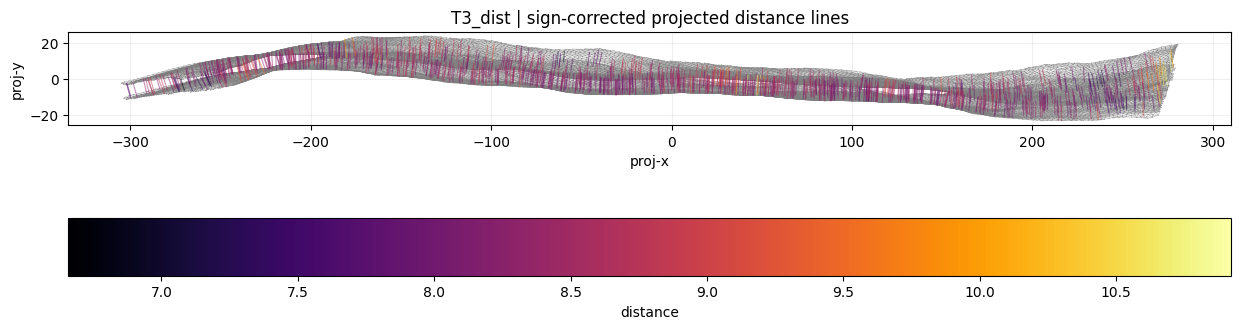

Mean viewing direction: [-0.03065738  0.00706911  0.99950495]
Used + direction for 0 lines
Used - direction for 22430 lines


In [13]:
source_mesh_path = "/scicore/home/engel0006/GROUP/pool-engel/HFSP/StateTransitions/Morphometrics/ST1_mm/ST1_5-2_Position_21/ST1_5-2_Position_21_trimed_components_T2.surface.vtp"
target_mesh_path = "/scicore/home/engel0006/GROUP/pool-engel/HFSP/StateTransitions/Morphometrics/ST1_mm/ST1_5-2_Position_21/ST1_5-2_Position_21_trimed_components_T3.surface.vtp"
csv_path         = "/scicore/home/engel0006/GROUP/pool-engel/HFSP/StateTransitions/Morphometrics/ST1_mm/ST1_5-2_Position_21/ST1_5-2_Position_21_trimed_components_T2.AVV_rh9.csv"

plot_projected_mesh_pair_with_distances(
    source_mesh_path=source_mesh_path,
    target_mesh_path=target_mesh_path,
    csv_path=csv_path,
    dist_col="T3_dist",
    vector_cols=("avg_normals_x", "avg_normals_y", "avg_normals_z"),
    step=20,
    source_color="grey",
    target_color="grey"
)